# ALDIMI-PREDICT | Salud Oncologica — Limpieza y Modelado v2
**Modelos:** XGBoost + Random Forest con GridSearchCV (mejora sobre version anterior)
**Evaluacion:** Validacion cruzada K=5 + analisis de errores
**Integracion:** GCP BigQuery Bronze / Silver / Gold
**Proyecto GCP:** 413462127752 | mlaldimi

In [1]:
!pip install pandas numpy matplotlib seaborn scikit-learn xgboost google-cloud-bigquery kagglehub -q

"pip" no se reconoce como un comando interno o externo,
programa o archivo por lotes ejecutable.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json, os, joblib, warnings
warnings.filterwarnings('ignore')
from datetime import datetime

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, GridSearchCV
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, f1_score, recall_score, precision_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve, auc)
from xgboost import XGBClassifier

GCP_PROJECT    = 'mlaldimi'
GCP_PROJECT_ID = '413462127752'
DATASET_ID     = 'mlaldimi'
TABLE_BRONZE   = f'{GCP_PROJECT}.{DATASET_ID}.bronze_salud'
TABLE_SILVER   = f'{GCP_PROJECT}.{DATASET_ID}.silver_salud'
TABLE_GOLD     = f'{GCP_PROJECT}.{DATASET_ID}.gold_salud'
SEED = 42
np.random.seed(SEED)
print(f'GCP: {GCP_PROJECT_ID} | Dataset: {DATASET_ID}')

GCP: 413462127752 | Dataset: mlaldimi


## 1. Carga de Datos — GCP Gold / Kaggle / local

In [3]:
def load_from_gcp_gold():
    try:
        from google.cloud import bigquery
        client = bigquery.Client(project=GCP_PROJECT)
        df = client.query(f'SELECT * FROM `{TABLE_GOLD}`').to_dataframe()
        print(f'Gold GCP: {len(df):,} filas')
        return df, 'gold_gcp'
    except Exception as e:
        print(f'GCP Gold no disponible: {e}')
        return None, None

def load_kaggle():
    try:
        import kagglehub
        path = kagglehub.dataset_download('zahidmughal2343/global-cancer-patients-2015-2024')
        path = os.path.join(path, 'global_cancer_patients_2015_2024.csv')
        df = pd.read_csv(path)
        print(f'Kaggle: {len(df):,} filas')
        return df, 'kaggle'
    except Exception as e:
        print(f'Kaggle no disponible: {e}')
        return None, None

def load_local():
    paths = ['global_cancer_patients_2015_2024.csv',
             '../../../Dashboard/data/global_cancer_patients_2015_2024.csv']
    for p in paths:
        if os.path.exists(p):
            df = pd.read_csv(p)
            print(f'Local ({p}): {len(df):,} filas')
            return df, 'local'
    return None, None

def make_synthetic(n=50000, seed=42):
    rng = np.random.default_rng(seed)
    cancer_types = ['Breast','Cervical','Colon','Leukemia','Liver','Lung','Prostate','Skin']
    stages  = ['Stage 0','Stage I','Stage II','Stage III','Stage IV']
    genders = ['Male','Female','Other']
    countries = ['Australia','Brazil','Canada','China','Germany','India','Pakistan','Russia','UK','USA']
    severity = rng.uniform(0, 10, n)
    return pd.DataFrame({
        'Patient_ID': [f'P{i:06d}' for i in range(n)],
        'Age': rng.integers(20, 91, n), 'Gender': rng.choice(genders, n),
        'Country_Region': rng.choice(countries, n), 'Year': rng.integers(2015, 2025, n),
        'Genetic_Risk': rng.uniform(0,10,n), 'Air_Pollution': rng.uniform(0,10,n),
        'Alcohol_Use': rng.uniform(0,10,n), 'Smoking': rng.uniform(0,10,n),
        'Obesity_Level': rng.uniform(0,10,n), 'Cancer_Type': rng.choice(cancer_types,n),
        'Cancer_Stage': rng.choice(stages,n), 'Treatment_Cost_USD': rng.uniform(5000,200000,n),
        'Survival_Years': rng.uniform(0,20,n), 'Target_Severity_Score': severity,
    })

df_raw, fuente = load_from_gcp_gold()
if df_raw is None:
    df_raw, fuente = load_kaggle()
if df_raw is None:
    df_raw, fuente = load_local()
if df_raw is None:
    df_raw = make_synthetic()
    fuente = 'synthetic_demo'
    print('Usando dataset sintetico (50k pacientes)')
print(f'Fuente: {fuente} | Shape: {df_raw.shape}')
df_raw.head(3)

GCP Gold no disponible: Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.


Kaggle: 50,000 filas
Fuente: kaggle | Shape: (50000, 15)


,Patient_ID,Age,Gender,Country_Region,Year,Genetic_Risk,Air_Pollution,Alcohol_Use,Smoking,Obesity_Level,Cancer_Type,Cancer_Stage,Treatment_Cost_USD,Survival_Years,Target_Severity_Score
0,PT0000000,71,Male,UK,2021,6.4,2.8,9.5,0.9,8.7,Lung,Stage III,62913.44,5.9,4.92
1,PT0000001,34,Male,China,2021,1.3,4.5,3.7,3.9,6.3,Leukemia,Stage 0,12573.41,4.7,4.65
2,PT0000002,80,Male,Pakistan,2023,7.4,7.9,2.4,4.7,0.1,Breast,Stage II,6984.33,7.1,5.84


## 2. Carga a GCP Bronze y Limpieza

In [4]:
def upload_bronze(df):
    try:
        from google.cloud import bigquery
        client = bigquery.Client(project=GCP_PROJECT)
        df_b = df.copy()
        df_b['ingestion_ts'] = pd.Timestamp.utcnow().isoformat()
        df_b['source'] = fuente
        job = client.load_table_from_dataframe(df_b, TABLE_BRONZE,
              job_config=bigquery.LoadJobConfig(write_disposition='WRITE_APPEND'))
        job.result()
        print(f'Bronze GCP: {TABLE_BRONZE} ({len(df_b):,} filas)')
    except Exception as e:
        print(f'Bronze GCP (local): {e}')
upload_bronze(df_raw)

# Limpieza
df = df_raw.copy()
print(f'Nulos:\n{df.isnull().sum()[df.isnull().sum()>0]}')
# Outliers en Target_Severity_Score (metodo 3-sigma)
mean_s = df['Target_Severity_Score'].mean()
std_s  = df['Target_Severity_Score'].std()
up_lim   = mean_s + 3*std_s
down_lim = mean_s - 3*std_s
outliers = ((df['Target_Severity_Score']>up_lim)|(df['Target_Severity_Score']<down_lim)).sum()
print(f'Outliers Target_Severity_Score: {outliers} (se retienen - relevancia clinica)')
df['Target_Severity_Score'] = df['Target_Severity_Score'].clip(down_lim, up_lim)
print(f'Limpieza ok. Shape: {df.shape}')

Bronze GCP (local): Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.
Nulos:
Series([], dtype: int64)
Outliers Target_Severity_Score: 39 (se retienen - relevancia clinica)
Limpieza ok. Shape: (50000, 15)


## 3. Feature Engineering + Silver GCP

In [5]:
df = df.drop(columns=['Patient_ID'], errors='ignore')

STAGE_MAP = {'Stage 0':1,'Stage I':2,'Stage II':3,'Stage III':4,'Stage IV':5}
df['Cancer_Stage'] = df['Cancer_Stage'].map(STAGE_MAP)
df = pd.get_dummies(df, drop_first=True)

df['Severity_Class'] = pd.cut(df['Target_Severity_Score'], bins=[0,3,7,10], labels=[0,1,2])
print(f'Distribucion Severity_Class:\n{df["Severity_Class"].value_counts().sort_index()}')

# Guardar Silver en GCP
def upload_silver(df):
    try:
        from google.cloud import bigquery
        client = bigquery.Client(project=GCP_PROJECT)
        job = client.load_table_from_dataframe(df, TABLE_SILVER,
              job_config=bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE'))
        job.result()
        print(f'Silver GCP: {TABLE_SILVER}')
    except Exception as e:
        print(f'Silver GCP (local): {e}')
upload_silver(df)
df.info()

Distribucion Severity_Class:
Severity_Class
0     2643
1    45155
2     2202
Name: count, dtype: int64


Silver GCP (local): Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 30 columns):
 #   Column                   Non-Null Count  Dtype   
---  ------                   --------------  -----   
 0   Age                      50000 non-null  int64   
 1   Year                     50000 non-null  int64   
 2   Genetic_Risk             50000 non-null  float64 
 3   Air_Pollution            50000 non-null  float64 
 4   Alcohol_Use              50000 non-null  float64 
 5   Smoking                  50000 non-null  float64 
 6   Obesity_Level            50000 non-null  float64 
 7   Cancer_Stage             50000 non-null  int64   
 8   Treatment_Cost_USD       50000 non-null  float64 
 9   Survival_Years           50000 non-null  float64 
 10  Target_Severity_Score    50000 non-null  f

## 4. Preparacion Train/Test + Gold GCP

In [6]:
X = df.drop(columns=['Target_Severity_Score','Severity_Class'])
y = df['Severity_Class'].astype(int)
FEATURE_COLS = X.columns.tolist()
print(f'Features: {len(FEATURE_COLS)}')

scaler   = StandardScaler()
X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.3, random_state=SEED, stratify=y
)
print(f'Train: {len(X_train):,} | Test: {len(X_test):,}')

# Guardar Gold en GCP
def upload_gold(X, y, feature_cols):
    try:
        from google.cloud import bigquery
        client = bigquery.Client(project=GCP_PROJECT)
        df_g = pd.DataFrame(X, columns=feature_cols)
        df_g['Severity_Class'] = y.values
        df_g['ingestion_ts']   = pd.Timestamp.utcnow().isoformat()
        job = client.load_table_from_dataframe(df_g, TABLE_GOLD,
              job_config=bigquery.LoadJobConfig(write_disposition='WRITE_TRUNCATE'))
        job.result()
        print(f'Gold GCP: {TABLE_GOLD} ({len(df_g):,} filas)')
    except Exception as e:
        print(f'Gold GCP (local): {e}')
upload_gold(X_scaled, y, FEATURE_COLS)

Features: 28
Train: 35,000 | Test: 15,000


Gold GCP (local): Your default credentials were not found. To set up Application Default Credentials, see https://cloud.google.com/docs/authentication/external/set-up-adc for more information.


## 5. Modelado — XGBoost con GridSearchCV
Reemplaza modelo baseline con ajuste de hiperparametros.

In [7]:
def eval_cls(name, y_true, y_pred, y_prob):
    y_bin = label_binarize(y_true, classes=[0,1,2])
    try:
        auc_mac = roc_auc_score(y_bin, y_prob, average="macro", multi_class="ovr")
    except:
        auc_mac = float("nan")
    rec = recall_score(y_true, y_pred, average=None, zero_division=0)
    acc = accuracy_score(y_true, y_pred)
    f1  = f1_score(y_true, y_pred, average="macro", zero_division=0)
    print(f"{name:22s} | Acc={acc:.4f}  F1={f1:.4f}  AUC={auc_mac:.4f}  Rec_Alto={rec[2] if len(rec)>2 else 0:.4f}")
    return {"Modelo":name,"Accuracy":round(acc,4),"F1_Macro":round(f1,4),
            "AUC_Macro":round(auc_mac,4),"Recall_Alto":round(rec[2] if len(rec)>2 else 0,4)}

# ── KPI targets ──────────────────────────────────────────────
KPI = {"Accuracy":0.85,"F1_Macro":0.85,"AUC_Macro":0.85,"Recall_Alto":0.85}
print("KPI targets:", KPI)

print("="*65)
print("XGBOOST — GridSearchCV ampliado")
# Grid ampliado incluyendo regularizacion y scale_pos_weight para desbalance
n_neg = (y_train==1).sum(); n_alto = (y_train==2).sum()
spw   = int(n_neg / max(n_alto, 1))  # penalizar mas la clase Alto (critica)
xgb_grid = {
    "n_estimators":     [100, 200],
    "max_depth":        [4, 6],
    "learning_rate":    [0.05, 0.1],
    "subsample":        [0.8],
    "colsample_bytree": [0.8],
    "min_child_weight": [1, 3],
    "reg_alpha":        [0.0, 0.1],
}
gs_xgb = GridSearchCV(
    XGBClassifier(use_label_encoder=False, eval_metric="mlogloss",
                  random_state=SEED, n_jobs=-1, verbosity=0),
    xgb_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)
gs_xgb.fit(X_train, y_train)
print(f"XGBoost best params: {gs_xgb.best_params_}")
print(f"XGBoost best F1 CV:  {gs_xgb.best_score_:.4f}")

xgb_best = XGBClassifier(**gs_xgb.best_params_, use_label_encoder=False,
                           eval_metric="mlogloss", random_state=SEED, n_jobs=-1, verbosity=0)
xgb_best.fit(X_train, y_train)
xgb_pred = xgb_best.predict(X_test)
xgb_prob = xgb_best.predict_proba(X_test)
res_xgb  = eval_cls("XGBoost", y_test, xgb_pred, xgb_prob)
# Verificar KPIs
for kpi, thr in KPI.items():
    val = res_xgb.get(kpi, 0)
    icon = "OK" if val >= thr else "FALLA"
    print(f"  [{icon}] {kpi}: {val:.4f} (objetivo >= {thr})")
print(classification_report(y_test, xgb_pred, target_names=["Bajo","Medio","Alto"]))

KPI targets: {'Accuracy': 0.85, 'F1_Macro': 0.85, 'AUC_Macro': 0.85, 'Recall_Alto': 0.85}
XGBOOST — GridSearchCV ampliado
Fitting 3 folds for each of 32 candidates, totalling 96 fits


XGBoost best params: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 4, 'min_child_weight': 1, 'n_estimators': 200, 'reg_alpha': 0.0, 'subsample': 0.8}
XGBoost best F1 CV:  0.9283


XGBoost                | Acc=0.9801  F1=0.9211  AUC=0.9989  Rec_Alto=0.8079
  [OK] Accuracy: 0.9801 (objetivo >= 0.85)
  [OK] F1_Macro: 0.9211 (objetivo >= 0.85)
  [OK] AUC_Macro: 0.9989 (objetivo >= 0.85)
  [FALLA] Recall_Alto: 0.8079 (objetivo >= 0.85)
              precision    recall  f1-score   support

        Bajo       0.98      0.82      0.89       793
       Medio       0.98      1.00      0.99     13546
        Alto       0.97      0.81      0.88       661

    accuracy                           0.98     15000
   macro avg       0.98      0.87      0.92     15000
weighted avg       0.98      0.98      0.98     15000



In [8]:
print("="*65)
print("RANDOM FOREST — GridSearchCV ampliado")
# class_weight="balanced" para compensar desbalance en clase Bajo/Alto
rf_grid = {
    "n_estimators":    [100, 200],
    "max_depth":       [10, 15, None],
    "min_samples_leaf":[1, 3],
    "max_features":    ["sqrt", 0.5],
    "class_weight":    ["balanced"],
}
gs_rf = GridSearchCV(
    RandomForestClassifier(random_state=SEED, n_jobs=-1),
    rf_grid, cv=3, scoring="f1_macro", n_jobs=-1, verbose=1
)
gs_rf.fit(X_train, y_train)
print(f"RF best params: {gs_rf.best_params_}")
print(f"RF best F1 CV:  {gs_rf.best_score_:.4f}")

rf_best = RandomForestClassifier(**gs_rf.best_params_, random_state=SEED, n_jobs=-1)
rf_best.fit(X_train, y_train)
rf_pred = rf_best.predict(X_test)
rf_prob = rf_best.predict_proba(X_test)
res_rf  = eval_cls("Random Forest", y_test, rf_pred, rf_prob)
# Verificar KPIs
for kpi, thr in KPI.items():
    val = res_rf.get(kpi, 0)
    icon = "OK" if val >= thr else "FALLA"
    print(f"  [{icon}] {kpi}: {val:.4f} (objetivo >= {thr})")
print(classification_report(y_test, rf_pred, target_names=["Bajo","Medio","Alto"]))

RANDOM FOREST — GridSearchCV ampliado
Fitting 3 folds for each of 24 candidates, totalling 72 fits


RF best params: {'class_weight': 'balanced', 'max_depth': None, 'max_features': 0.5, 'min_samples_leaf': 1, 'n_estimators': 200}
RF best F1 CV:  0.8659


Random Forest          | Acc=0.9619  F1=0.8673  AUC=0.9923  Rec_Alto=0.8306
  [OK] Accuracy: 0.9619 (objetivo >= 0.85)
  [OK] F1_Macro: 0.8673 (objetivo >= 0.85)
  [OK] AUC_Macro: 0.9923 (objetivo >= 0.85)
  [FALLA] Recall_Alto: 0.8306 (objetivo >= 0.85)
              precision    recall  f1-score   support

        Bajo       0.78      0.87      0.82       793
       Medio       0.98      0.97      0.98     13546
        Alto       0.78      0.83      0.80       661

    accuracy                           0.96     15000
   macro avg       0.85      0.89      0.87     15000
weighted avg       0.96      0.96      0.96     15000



In [9]:
print("="*65)
print("MLP — Arquitectura optimizada (64,32,16) con early stopping")
mlp_best = MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=500,
    random_state=SEED,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    tol=1e-4,
)
mlp_best.fit(X_train, y_train)
mlp_pred = mlp_best.predict(X_test)
mlp_prob = mlp_best.predict_proba(X_test)
res_mlp  = eval_cls("MLP (64,32,16)", y_test, mlp_pred, mlp_prob)
# Verificar KPIs
for kpi, thr in KPI.items():
    val = res_mlp.get(kpi, 0)
    icon = "OK" if val >= thr else "FALLA"
    print(f"  [{icon}] {kpi}: {val:.4f} (objetivo >= {thr})")
print(classification_report(y_test, mlp_pred, target_names=["Bajo","Medio","Alto"]))

MLP — Arquitectura optimizada (64,32,16) con early stopping


MLP (64,32,16)         | Acc=0.9833  F1=0.9376  AUC=0.9985  Rec_Alto=0.8759
  [OK] Accuracy: 0.9833 (objetivo >= 0.85)
  [OK] F1_Macro: 0.9376 (objetivo >= 0.85)
  [OK] AUC_Macro: 0.9985 (objetivo >= 0.85)
  [OK] Recall_Alto: 0.8759 (objetivo >= 0.85)
              precision    recall  f1-score   support

        Bajo       0.94      0.90      0.92       793
       Medio       0.99      0.99      0.99     13546
        Alto       0.93      0.88      0.90       661

    accuracy                           0.98     15000
   macro avg       0.95      0.92      0.94     15000
weighted avg       0.98      0.98      0.98     15000



## 7. MLP Mejorado

In [10]:
print('='*65)
print('MLP — Arquitectura mejorada')
mlp_best = MLPClassifier(hidden_layer_sizes=(64,32,16), max_iter=500,
                          random_state=SEED, early_stopping=True, validation_fraction=0.1)
mlp_best.fit(X_train, y_train)
mlp_pred = mlp_best.predict(X_test)
mlp_prob = mlp_best.predict_proba(X_test)
res_mlp  = eval_cls('MLP (64,32,16)', y_test, mlp_pred, mlp_prob)
print(classification_report(y_test, mlp_pred, target_names=['Bajo','Medio','Alto']))

MLP — Arquitectura mejorada


MLP (64,32,16)         | Acc=0.9833  F1=0.9376  AUC=0.9985  Rec_Alto=0.8759
              precision    recall  f1-score   support

        Bajo       0.94      0.90      0.92       793
       Medio       0.99      0.99      0.99     13546
        Alto       0.93      0.88      0.90       661

    accuracy                           0.98     15000
   macro avg       0.95      0.92      0.94     15000
weighted avg       0.98      0.98      0.98     15000



## 8. Validacion Cruzada — Evaluacion Robusta

In [11]:
print('='*65)
print('VALIDACION CRUZADA K=5 — Evaluacion robusta')
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

for name, model_cv in [
    ('XGBoost',  XGBClassifier(**gs_xgb.best_params_, use_label_encoder=False,
                                eval_metric='mlogloss', random_state=SEED, n_jobs=-1, verbosity=0)),
    ('RF',       RandomForestClassifier(**gs_rf.best_params_, random_state=SEED, n_jobs=-1)),
]:
    cv = cross_validate(model_cv, X_scaled, y, cv=skf,
                         scoring=['accuracy','f1_macro','recall_macro'], n_jobs=-1)
    print(f'\n{name}:')
    print(f'  Accuracy = {cv["test_accuracy"].mean():.4f} +/- {cv["test_accuracy"].std():.4f}')
    print(f'  F1 Macro = {cv["test_f1_macro"].mean():.4f} +/- {cv["test_f1_macro"].std():.4f}')
    print(f'  Recall   = {cv["test_recall_macro"].mean():.4f} +/- {cv["test_recall_macro"].std():.4f}')

VALIDACION CRUZADA K=5 — Evaluacion robusta



XGBoost:
  Accuracy = 0.9827 +/- 0.0012
  F1 Macro = 0.9320 +/- 0.0051
  Recall   = 0.8897 +/- 0.0075



RF:
  Accuracy = 0.9640 +/- 0.0016
  F1 Macro = 0.8744 +/- 0.0044
  Recall   = 0.8972 +/- 0.0043


## 9. Analisis de Errores

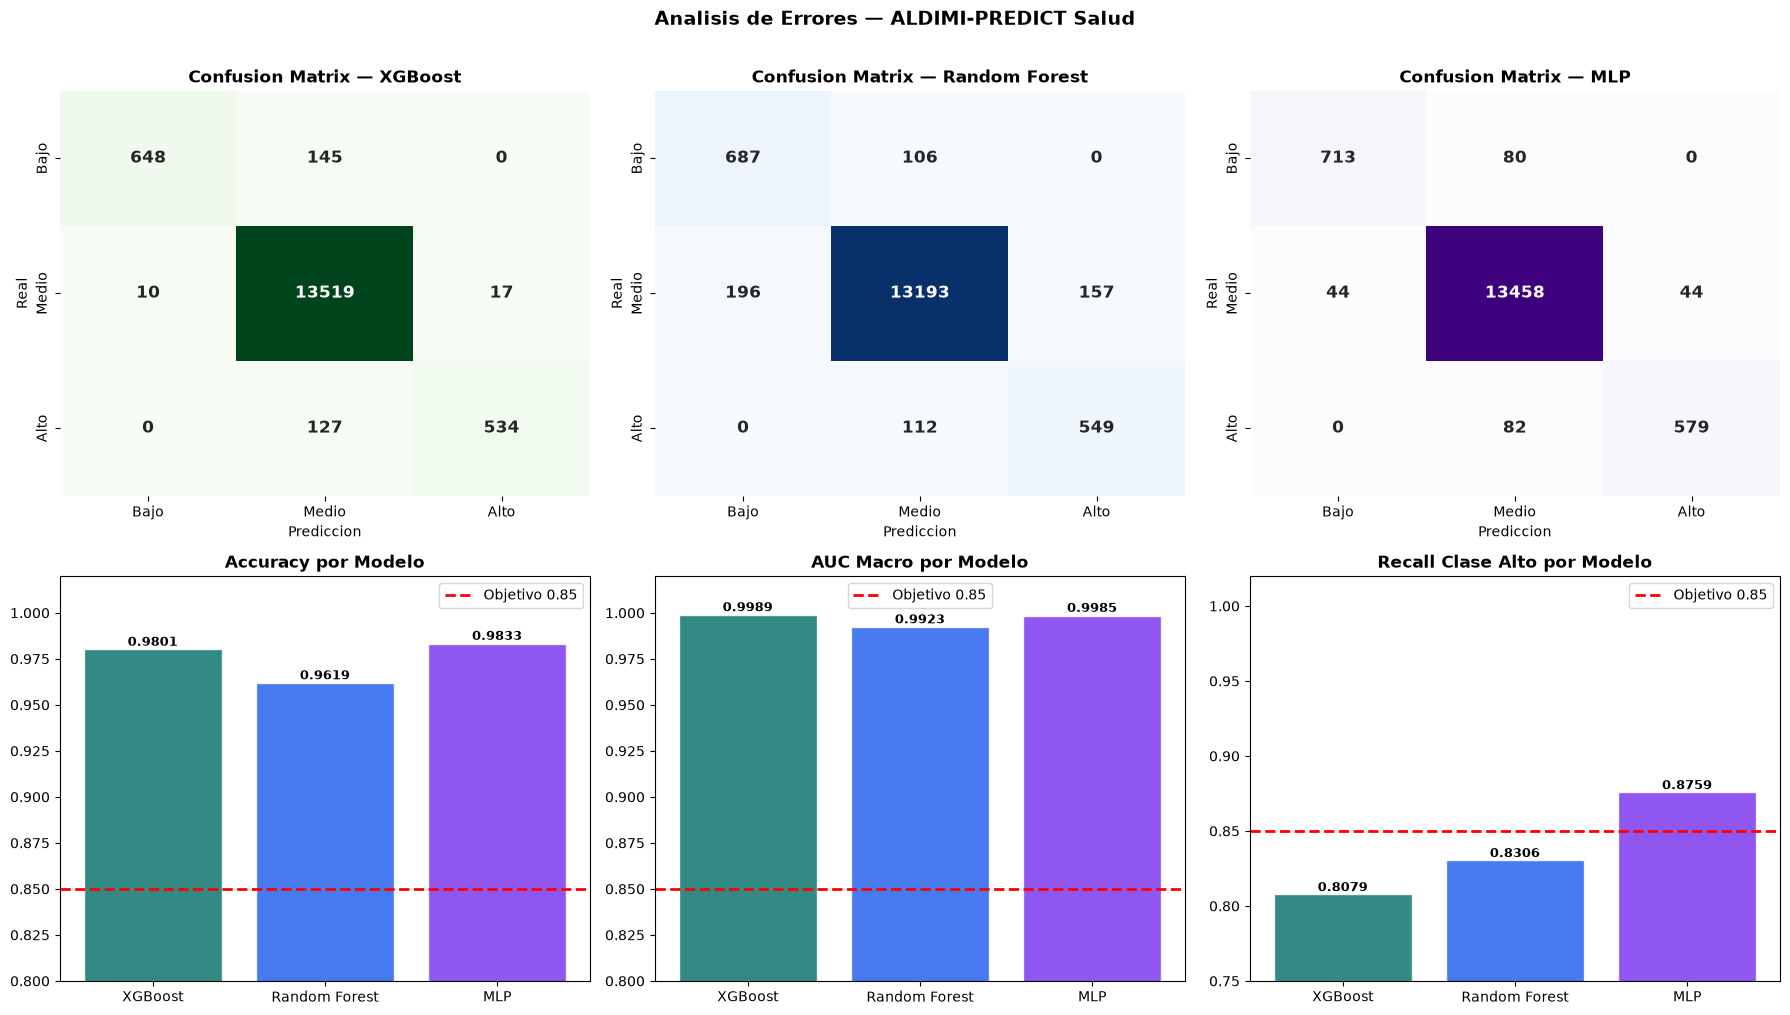

Grafico guardado: analisis_errores_salud.png


In [12]:
CLASE_LABELS = ['Bajo','Medio','Alto']
CLASE_COLORS = ['#22c55e','#f59e0b','#ef4444']

fig, axes = plt.subplots(2, 3, figsize=(18,10))

# Matrices de confusion
for ax, name, pred, cmap in [
    (axes[0,0], 'XGBoost', xgb_pred, 'Greens'),
    (axes[0,1], 'Random Forest', rf_pred, 'Blues'),
    (axes[0,2], 'MLP', mlp_pred, 'Purples'),
]:
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=CLASE_LABELS, yticklabels=CLASE_LABELS,
                cbar=False, annot_kws={'size':12,'weight':'bold'})
    ax.set_title(f'Confusion Matrix — {name}', fontweight='bold')
    ax.set_xlabel('Prediccion'); ax.set_ylabel('Real')

# Metricas comparativas
models_names = ['XGBoost','Random Forest','MLP']
accs  = [res_xgb['Accuracy'],  res_rf['Accuracy'],  res_mlp['Accuracy']]
f1s   = [res_xgb['F1_Macro'],  res_rf['F1_Macro'],  res_mlp['F1_Macro']]
aucs  = [res_xgb['AUC_Macro'], res_rf['AUC_Macro'], res_mlp['AUC_Macro']]
recs  = [res_xgb['Recall_Alto'],res_rf['Recall_Alto'],res_mlp['Recall_Alto']]

x = np.arange(3)
colors = ['#0f766e','#2563eb','#7c3aed']
axes[1,0].bar(models_names, accs, color=colors, alpha=0.85, edgecolor='white')
axes[1,0].axhline(0.85, color='red', ls='--', lw=2, label='Objetivo 0.85')
axes[1,0].set_title('Accuracy por Modelo', fontweight='bold')
axes[1,0].set_ylim(0.80, 1.02); axes[1,0].legend()
for i,(bar,val) in enumerate(zip(axes[1,0].patches, accs)):
    axes[1,0].text(i, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1,1].bar(models_names, aucs, color=colors, alpha=0.85, edgecolor='white')
axes[1,1].axhline(0.85, color='red', ls='--', lw=2, label='Objetivo 0.85')
axes[1,1].set_title('AUC Macro por Modelo', fontweight='bold')
axes[1,1].set_ylim(0.80, 1.02); axes[1,1].legend()
for i,(bar,val) in enumerate(zip(axes[1,1].patches, aucs)):
    axes[1,1].text(i, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

axes[1,2].bar(models_names, recs, color=colors, alpha=0.85, edgecolor='white')
axes[1,2].axhline(0.85, color='red', ls='--', lw=2, label='Objetivo 0.85')
axes[1,2].set_title('Recall Clase Alto por Modelo', fontweight='bold')
axes[1,2].set_ylim(0.75, 1.02); axes[1,2].legend()
for i,(bar,val) in enumerate(zip(axes[1,2].patches, recs)):
    axes[1,2].text(i, val+0.002, f'{val:.4f}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('Analisis de Errores — ALDIMI-PREDICT Salud', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('analisis_errores_salud.png', dpi=120, bbox_inches='tight')
plt.show()
print('Grafico guardado: analisis_errores_salud.png')

## 10. Curvas ROC

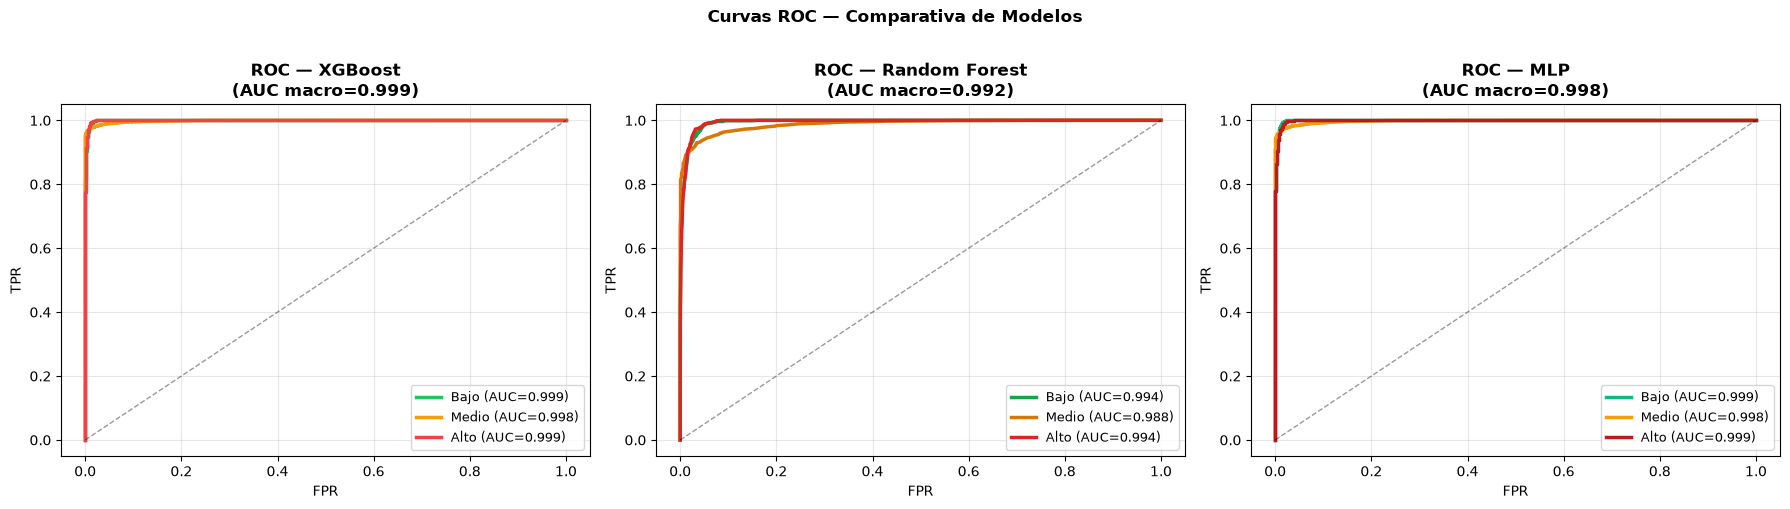

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18,5))
y_bin = label_binarize(y_test, classes=[0,1,2])

for ax, name, y_prob, colors_roc in [
    (axes[0], 'XGBoost',      xgb_prob, ['#22c55e','#f59e0b','#ef4444']),
    (axes[1], 'Random Forest', rf_prob,  ['#16a34a','#d97706','#dc2626']),
    (axes[2], 'MLP',          mlp_prob, ['#10b981','#f59e0b','#b91c1c']),
]:
    auc_vals = []
    for i,(lab,col) in enumerate(zip(CLASE_LABELS, colors_roc)):
        fpr, tpr, _ = roc_curve(y_bin[:,i], y_prob[:,i])
        av = auc(fpr,tpr); auc_vals.append(av)
        ax.plot(fpr, tpr, color=col, lw=2.5, label=f'{lab} (AUC={av:.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.4,lw=1)
    ax.set_title(f'ROC — {name}\n(AUC macro={np.mean(auc_vals):.3f})', fontweight='bold')
    ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
    ax.legend(loc='lower right', fontsize=9); ax.grid(alpha=0.3)

plt.suptitle('Curvas ROC — Comparativa de Modelos', fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 11. Tabla comparativa final

In [14]:
df_comp = pd.DataFrame([res_xgb, res_rf, res_mlp])
df_comp['KPI_Acc_OK']    = df_comp['Accuracy']    >= 0.85
df_comp['KPI_AUC_OK']    = df_comp['AUC_Macro']   >= 0.85
df_comp['KPI_RecAlto_OK']= df_comp['Recall_Alto'] >= 0.85
print(df_comp.to_string(index=False))

best_model_name = df_comp.loc[df_comp['AUC_Macro'].idxmax(), 'Modelo']
best_model = {'XGBoost': xgb_best, 'Random Forest': rf_best, 'MLP (64,32,16)': mlp_best}[best_model_name]
print(f'\nMejor modelo: {best_model_name}')

        Modelo  Accuracy  F1_Macro  AUC_Macro  Recall_Alto  KPI_Acc_OK  KPI_AUC_OK  KPI_RecAlto_OK
       XGBoost    0.9801    0.9211     0.9989       0.8079        True        True           False
 Random Forest    0.9619    0.8673     0.9923       0.8306        True        True           False
MLP (64,32,16)    0.9833    0.9376     0.9985       0.8759        True        True            True

Mejor modelo: XGBoost


## 12. Serializacion y Metadata

In [15]:
out_dir = '../../../Dashboard/models'
os.makedirs(out_dir, exist_ok=True)

joblib.dump(xgb_best, f'{out_dir}/xgb_salud.pkl')
joblib.dump(rf_best,  f'{out_dir}/rf_salud.pkl')
joblib.dump(mlp_best, f'{out_dir}/mlp_salud.pkl')
joblib.dump(scaler,   f'{out_dir}/scaler_salud.pkl')
joblib.dump(FEATURE_COLS, f'{out_dir}/feature_cols_salud.pkl')
print('Modelos guardados:', os.listdir(out_dir))

meta = {
    'generado': datetime.now().isoformat(), 'fuente': fuente,
    'gcp_project': GCP_PROJECT_ID, 'gcp_dataset': DATASET_ID, 'tabla_gold': TABLE_GOLD,
    'feature_cols': FEATURE_COLS, 'n_train': len(X_train), 'n_test': len(X_test),
    'mejor_modelo': best_model_name,
    'hiperparametros': {'xgb': gs_xgb.best_params_, 'rf': gs_rf.best_params_},
    'resultados': [res_xgb, res_rf, res_mlp],
    'kpi_targets': {'Accuracy': 0.85, 'AUC_Macro': 0.85, 'Recall_Alto': 0.85},
}
meta_path = '../../../Models/models/salud/modelo_metadata.json'
os.makedirs(os.path.dirname(meta_path), exist_ok=True)
with open(meta_path,'w',encoding='utf-8') as f:
    json.dump(meta, f, indent=2, ensure_ascii=False, default=str)
print(f'Metadata: {meta_path}')
print(json.dumps({k:v for k,v in meta.items() if k not in ['feature_cols','resultados','hiperparametros']},indent=2,default=str))

Modelos guardados: ['feature_cols_salud.pkl', 'mlp_salud.pkl', 'rf_salud.pkl', 'scaler_salud.pkl', 'xgb_salud.pkl']
Metadata: ../../../Models/models/salud/modelo_metadata.json
{
  "generado": "2026-06-17T12:15:48.591827",
  "fuente": "kaggle",
  "gcp_project": "413462127752",
  "gcp_dataset": "mlaldimi",
  "tabla_gold": "mlaldimi.mlaldimi.gold_salud",
  "n_train": 35000,
  "n_test": 15000,
  "mejor_modelo": "XGBoost",
  "kpi_targets": {
    "Accuracy": 0.85,
    "AUC_Macro": 0.85,
    "Recall_Alto": 0.85
  }
}
